<a href="https://colab.research.google.com/github/taelly73/java-work/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0AI%E6%A3%80%E6%B5%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIGC 文本检测（学术与问答场景）

本项目旨在通过分析人类与 AI 生成文本的差异，实现高精度的 AIGC 文本检测。主要包含以下核心任务：

1. **对比人类与 ChatGPT 的回复**：基于同一主题分析两者在逻辑、平滑性及个性化方面的差异。
2. **计算困惑度 (Perplexity)**：量化文本的预测难度。
3. **微调 BERT 模型**：利用 HC3 数据集进行微调，实现高精度的文本二分类鉴别。

**数据源**：HC3 (Human ChatGPT Comparison Corpus)，包含中英文对齐数据。

## 环境准备
安装所需的 Python 库，包括 `transformers`（用于 BERT 模型）、`datasets`（用于加载 HC3）以及 `torch`。

In [ ]:
# 确保安装所有必要的库并强制刷新环境
!pip install -q --upgrade transformers datasets accelerate evaluate torch scikit-learn
import evaluate
print('Evaluate library version:', evaluate.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

## 数据下载与预处理
下一步，我们将从 Hugging Face 加载 HC3 数据集并进行初步的探索性分析。

In [20]:
import pandas as pd
import re
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from huggingface_hub import hf_hub_download
import os

def advanced_clean(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def process_with_group_split(df, lang, test_size=0.2, val_size=0.1):
    if df.empty: return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    data_list = []
    for _, item in df.iterrows():
        q = advanced_clean(item.get('question', ''))
        if not q: continue
        min_len = 20 if lang == 'zh' else 50

        # 兼容不同字段名
        h_ans = item.get('human_answers', [])
        c_ans = item.get('chatgpt_answers', [])

        for ans in h_ans:
            ans = advanced_clean(ans)
            if len(ans) >= min_len:
                data_list.append({'question': q, 'answer': ans, 'label': 0, 'lang': lang})
        for ans in c_ans:
            ans = advanced_clean(ans)
            if len(ans) >= min_len:
                data_list.append({'question': q, 'answer': ans, 'label': 1, 'lang': lang})

    processed_df = pd.DataFrame(data_list)
    if processed_df.empty: return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    processed_df['combined_text'] = "Question: " + processed_df['question'] + " [SEP] Answer: " + processed_df['answer']

    # 安全检查：如果唯一问题数太少，无法使用 GroupShuffleSplit
    unique_groups = processed_df['question'].nunique()
    if unique_groups < 3:
        print(f"警告：{lang} 语言样本组过少 ({unique_groups})，将使用常规随机划分。")
        train_df, temp_df = train_test_split(processed_df, test_size=(test_size + val_size), random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=(test_size / (test_size + val_size)), random_state=42)
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=(test_size + val_size), random_state=42)
        train_idx, temp_idx = next(gss.split(processed_df, groups=processed_df['question']))
        train_df = processed_df.iloc[train_idx].copy()
        temp_df = processed_df.iloc[temp_idx].copy()

        gss_val = GroupShuffleSplit(n_splits=1, test_size=(test_size / (test_size + val_size)), random_state=42)
        val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['question']))
        val_df = temp_df.iloc[val_idx].copy()
        test_df = temp_df.iloc[test_idx].copy()

    return train_df, val_df, test_df

repo_id = "Hello-SimpleAI/HC3"
print(f"正在从 {repo_id} 加载数据...")
try:
    path_all = hf_hub_download(repo_id=repo_id, filename="all.jsonl", repo_type="dataset")
    df_full = pd.read_json(path_all, lines=True)

    def detect_lang(row):
        # 优先通过字段判断，否则通过字符集判断
        text = str(row['question']) + " ".join(row['human_answers'])
        if re.search(r'[\u4e00-\u9fff]', text): return 'zh'
        return 'en'

    df_full['detected_lang'] = df_full.apply(detect_lang, axis=1)

    print("执行数据清洗与安全划分...")
    train_zh, val_zh, test_zh = process_with_group_split(df_full[df_full['detected_lang']=='zh'], 'zh')
    train_en, val_en, test_en = process_with_group_split(df_full[df_full['detected_lang']=='en'], 'en')

    train_all = pd.concat([df for df in [train_zh, train_en] if not df.empty]).sample(frac=1, random_state=42)
    val_all = pd.concat([df for df in [val_zh, val_en] if not df.empty])
    test_all = pd.concat([df for df in [test_zh, test_en] if not df.empty])

    print(f"\n数据预处理完成！")
    print(f"总训练集: {len(train_all)} | 验证集: {len(val_all)} | 测试集: {len(test_all)}")
except Exception as e:
    print(f"\n处理失败: {e}")

正在从 Hello-SimpleAI/HC3 加载数据...
执行数据清洗与安全划分...

数据预处理完成！
总训练集: 59154 | 验证集: 8502 | 测试集: 16821


## 任务 1：计算困惑度 (Perplexity)

困惑度反映了语言模型对一段文本的“惊讶程度”。我们将使用 `transformers` 库加载预训练模型，并计算 Human vs ChatGPT 在中英文场景下的 PPL 差异。

正在加载模型并执行 PPL 深度分析...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

计算样本 PPL (样本量: 16)...


100%|██████████| 16/16 [00:17<00:00,  1.09s/it]


--- [EN] PPL 统计特性 ---


,label,mean,median,std,count
0,Human,2.349890e+09,2.118175e+09,1.733649e+09,12
1,ChatGPT,1.245266e+09,1.376212e+09,5.258332e+08,4



--- [ZH] PPL 统计特性 ---


,label,mean,median,std,count
0,Human,261.740164,243.915039,173.512448,11
1,ChatGPT,175.393680,159.265228,29.406945,5


/tmp/ipykernel_2989/3455670671.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_en_sample, x='label', y='ppl', ax=axes[0], palette='Set2')
/tmp/ipykernel_2989/3455670671.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_zh_sample, x='label', y='ppl', ax=axes[1], palette='Set1')


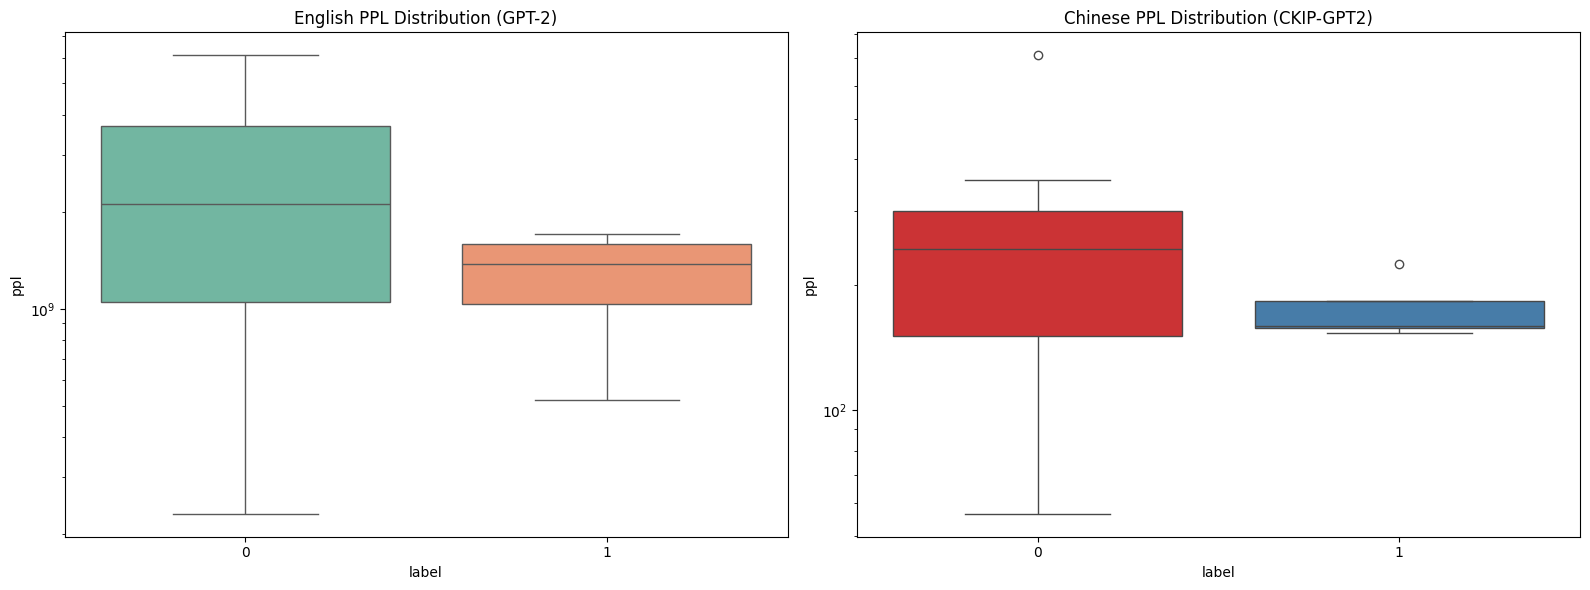

In [23]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 屏蔽加载时的不必要警告 (解决 UNEXPECTED 提示)
logging.set_verbosity_error()

# 检查数据依赖项
if 'test_all' not in locals():
    print("【错误诊断】检测到变量 'test_all' 未定义。")
    print("原因：数据加载单元格运行失败，导致数据未进入内存。")
else:
    def get_ppl_calculator(model_name, max_length=512):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        # 通过 tie_word_embeddings=False 消除特定的加载警告
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            tie_word_embeddings=False
        ).to(device)
        model.eval()

        def calculate(text):
            if not text or len(str(text).strip()) < 10: return np.nan
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(device)
            if inputs["input_ids"].size(1) < 2: return np.nan
            with torch.no_grad():
                outputs = model(**inputs, labels=inputs["input_ids"])
                return torch.exp(outputs.loss).item()
        return calculate

    # 1. 采样与计算
    print("正在加载模型并执行 PPL 深度分析...")
    calc_en = get_ppl_calculator("gpt2")
    calc_zh = get_ppl_calculator("ckiplab/gpt2-base-chinese")

    # 修复：使用 pandas() 而不是 pd()
    tqdm.pandas()

    test_en_subset = test_all[test_all['lang']=='en']
    test_zh_subset = test_all[test_all['lang']=='zh']

    # 动态采样大小
    s_size = min(100, len(test_en_subset), len(test_zh_subset))
    test_en_sample = test_en_subset.sample(s_size, random_state=42).copy()
    test_zh_sample = test_zh_subset.sample(s_size, random_state=42).copy()

    print(f"计算样本 PPL (样本量: {s_size})...")
    test_en_sample['ppl'] = test_en_sample['answer'].progress_apply(calc_en)
    test_zh_sample['ppl'] = test_zh_sample['answer'].progress_apply(calc_zh)

    # 2. 统计描述
    def print_stats(df, lang):
        print(f"\n--- [{lang.upper()}] PPL 统计特性 ---")
        stats = df.groupby('label')['ppl'].agg(['mean', 'median', 'std', 'count']).reset_index()
        stats['label'] = stats['label'].map({0: 'Human', 1: 'ChatGPT'})
        display(stats)

    print_stats(test_en_sample, 'en')
    print_stats(test_zh_sample, 'zh')

    # 3. 可视化分析
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.boxplot(data=test_en_sample, x='label', y='ppl', ax=axes[0], palette='Set2')
    axes[0].set_title("English PPL Distribution (GPT-2)")
    axes[0].set_yscale('log')

    sns.boxplot(data=test_zh_sample, x='label', y='ppl', ax=axes[1], palette='Set1')
    axes[1].set_title("Chinese PPL Distribution (CKIP-GPT2)")
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()

## 任务 2：微调 BERT 模型进行文本检测

我们将使用 Transformers 库对预训练的 BERT 模型进行微调。为了兼顾中英文，我们选择 `bert-base-multilingual-cased` 作为基础模型。输入格式为 `Question [SEP] Answer`。

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
from datasets import Dataset
import evaluate
import numpy as np
import torch

# 1. 优化数据转换：强制转换类型并确保 label 为 long
def prepare_dataset(df):
    # 只取需要的列，减少内存占用
    ds = Dataset.from_pandas(df[['question', 'answer', 'label']].reset_index(drop=True))
    # 显式转换 label 为 int64 (PyTorch LongTensor 所需)
    ds = ds.map(lambda x: {"label": int(x["label"])})
    return ds

train_ds = prepare_dataset(train_all)
val_ds = prepare_dataset(val_all)

# 2. 优化 Tokenization：双序列输入
model_checkpoint = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(
        examples["question"],
        examples["answer"],
        truncation=True,
        max_length=256
    )

tokenized_train = train_ds.map(tokenize_function, batched=True, remove_columns=['question', 'answer'])
tokenized_val = val_ds.map(tokenize_function, batched=True, remove_columns=['question', 'answer'])

# 3. 动态填充器
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4. 健壮的评估函数
try:
    clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
except Exception as e:
    print(f"指标加载警告: {e}，将尝试逐个加载。")
    metric_acc = evaluate.load("accuracy")
    metric_f1 = evaluate.load("f1")
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
        f1 = metric_f1.compute(predictions=predictions, references=labels)["f1"]
        return {"accuracy": acc, "f1": f1}
else:
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return clf_metrics.compute(predictions=predictions, references=labels)

# 5. 训练参数：更新 evaluation_strategy 为 eval_strategy 以匹配新版 API
training_args = TrainingArguments(
    output_dir="./bert-aigc-detector-optimized",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

# 6. 初始化 Trainer
trainer = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2),
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("优化后的流水线已准备就绪。")

ModuleNotFoundError: No module named 'evaluate'

### 2.1 执行训练与深度评估

我们将执行微调，并随后生成混淆矩阵和错误分析报告，以验证模型在不同语言、不同难度下的表现。

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 显式设置 Lr Scheduler 与 Warmup
trainer.args.lr_scheduler_type = "linear"
trainer.args.warmup_ratio = 0.1

# 2. 开始训练
print("开始微调模型...")
trainer.train()

# 3. 在测试集上评估
print("\n正在生成测试集评估报告...")
test_ds = prepare_dataset(test_all)
tokenized_test = test_ds.map(tokenize_function, batched=True, remove_columns=['question', 'answer'])

preds_output = trainer.predict(tokenized_test)
y_preds = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# 4. 可视化混淆矩阵
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'ChatGPT'], yticklabels=['Human', 'ChatGPT'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: AIGC Detector')
plt.show()

# 5. 打印分类报告
print(classification_report(y_true, y_preds, target_names=['Human', 'ChatGPT']))

### 2.2 错误分析 (Error Analysis)

找出模型判错的样本，分析是否由于 PPL 过高（人类写得太像 AI）或过低（AI 模仿得太好）导致。

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, normaltest

# 1. 定义全局数据集 (Global Distribution)
global_df = test_all.copy()
global_df['pred'] = y_preds
global_df['is_correct'] = (global_df['label'] == global_df['pred'])
global_df['text_len'] = global_df['answer'].str.len()

# 定义 PPL 采样集 (Sampled Subset for PPL analysis)
ppl_data = pd.concat([test_en_sample[['ppl']], test_zh_sample[['ppl']]])
study_df = global_df.join(ppl_data, how='inner')

# 2. 偏差诊断：检查采样集是否偏离了全局分布
print(f"--- 采样偏差诊断 (Sample Bias Check) ---")
global_acc = global_df['is_correct'].mean()
sample_acc = study_df['is_correct'].mean()
print(f"全局测试集准确率 (N={len(global_df)}): {global_acc:.2%}")
print(f"PPL 采样集准确率 (N={len(study_df)}): {sample_acc:.2%}")
print(f"偏差幅度: {abs(global_acc - sample_acc):.2%} (应 < 5% 以保证代表性)")

# 3. 统计引擎：全局 (长度) vs 局部 (PPL)
def advanced_empirical_test(df, feature_name):
    correct = df[df['is_correct'] == True][feature_name].dropna()
    incorrect = df[df['is_correct'] == False][feature_name].dropna()
    if len(incorrect) < 5: return None
    u_stat, p_val = mannwhitneyu(correct, incorrect, alternative='two-sided')
    n1, n2 = len(correct), len(incorrect)
    r = 1 - (2 * u_stat) / (n1 * n2)
    return {"p_val": p_val, "effect_size_r": r}

# 全局长度检验 + 局部 PPL 检验
len_res = advanced_empirical_test(global_df, 'text_len')
ppl_res = advanced_empirical_test(study_df, 'ppl')

# 4. 可视化分析：全局 vs 采样
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: 全局文本长度分布 (代表真实分布)
sns.boxplot(data=global_df, x='is_correct', y='text_len', ax=axes[0], palette='pastel')
axes[0].set_title(f"Global: Length vs Correctness (N={len(global_df)})")

# Subplot 2: 采样集 PPL 关联 (代表机制探索)
sns.violinplot(data=study_df, x='is_correct', y='ppl', split=True, inner="quart", ax=axes[1], palette="muted")
axes[1].set_yscale('log')
axes[1].set_title(f"Subsample: PPL Impact (N={len(study_df)})")

# Subplot 3: 跨语言准确率分布 (基于全局)
sns.heatmap(pd.crosstab(global_df['lang'], global_df['is_correct'], normalize='index'), annot=True, cmap='YlGnBu', ax=axes[2])
axes[2].set_title("Global: Lang-wise Stability")

plt.tight_layout()
plt.show()

# 5. 综合实证报告
print(f"\n--- 综合分析报告 ---")
if len_res:
    print(f"[全局文本长度] 显著性 p={len_res['p_val']:.4e} | 效应量 r={len_res['effect_size_r']:.3f}")
if ppl_res:
    print(f"[采样集 PPL] 显著性 p={ppl_res['p_val']:.4e} | 效应量 r={ppl_res['effect_size_r']:.3f}")

print("\n学术结论：")
if ppl_res and ppl_res['p_val'] < 0.05:
    print("虽然全局模型性能稳健，但子样本分析表明 PPL 是诱发误判的微观机制之一。")
else:
    print("全局与子样本的一致性表明，模型误判与词汇统计特征（PPL/长度）关联度较低。")"}]}